# CA 24 - Theory Assignment 1: Multi-Output Time-Series Forecasting
## NIFTY-50 Stock Market Data | LSTM / GRU | PyTorch

**Dataset:** POWERGRID.csv (Roll No. 37)  
**Task:** Given the last N days of all 11 features, predict the next 5 days of all 11 features.  
**Framework:** PyTorch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math, warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

KeyboardInterrupt: 

## 1 Load Dataset

In [2]:
CSV_PATH   = r"dataset/nifty50/POWERGRID.csv"
INPUT_LEN  = 10   # look-back window (days)
OUTPUT_LEN = 5    # forecast horizon (days)
OVERLAP    = 5    # stride = INPUT_LEN - OVERLAP  ->  step of 5 days
BATCH_SIZE = 64
EPOCHS     = 50
LR         = 1e-3
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT    = 0.2
TEST_RATIO = 0.2

df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded {CSV_PATH}  ->  shape: {df_raw.shape}")
print(df_raw.head(3))

Loaded dataset/nifty50/POWERGRID.csv  ->  shape: (3359, 15)
         Date     Symbol Series  Prev Close   Open    High    Low   Last  \
0  2007-10-05  POWERGRID     EQ       52.00   89.8  109.50  83.15  100.2   
1  2007-10-08  POWERGRID     EQ      100.60  104.0  104.00  94.85   95.3   
2  2007-10-09  POWERGRID     EQ       95.45   95.5  102.85  90.35  102.1   

    Close    VWAP     Volume      Turnover  Trades  Deliverable Volume  \
0  100.60  102.49  481058927  4.930561e+15     NaN           181390171   
1   95.45   98.12   71252858  6.991616e+14     NaN            22115293   
2  101.95   98.57   65658228  6.471784e+14     NaN            16991920   

   %Deliverble  
0       0.3771  
1       0.3104  
2       0.2588  


## 2 . Data Cleaning

In [3]:
df = df_raw.copy()

# 1. Parse & sort dates
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# 2. Remove exact duplicate rows
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicate rows removed: {n_dup}")

# 3. Detect & fix the 11 feature columns
# The dataset may have "%Deliverble" instead of a separate "Deliverable Volume"
# We keep both if present; otherwise derive %Deliverble from what's available.
present_cols = df.columns.tolist()
print("Columns in file:", present_cols)

# Build the actual feature list from what exists in the file
candidate_features = [
    "Prev Close", "Open", "High", "Low", "Last",
    "Close", "VWAP", "Volume", "Turnover", "Trades",
    "Deliverable Volume", "%Deliverble"
]
FEATURE_COLS = [c for c in candidate_features if c in present_cols]
print(f"Using {len(FEATURE_COLS)} feature columns: {FEATURE_COLS}")

# -- 4. Handle missing / NaN values -------------------------------------------
print("\nMissing values before cleaning:")
print(df[FEATURE_COLS].isnull().sum())

# Forward-fill first (carry last known value), then back-fill for leading NaNs
df[FEATURE_COLS] = df[FEATURE_COLS].ffill().bfill()

print("\nMissing values after cleaning:")
print(df[FEATURE_COLS].isnull().sum())

# -- 5. Ensure numeric types ---------------------------------------------------
for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dropna(subset=FEATURE_COLS, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nFinal dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()}  ->  {df['Date'].max().date()}")

Duplicate rows removed: 0
Columns in file: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']
Using 12 feature columns: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

Missing values before cleaning:
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                903
Deliverable Volume      0
%Deliverble             0
dtype: int64

Missing values after cleaning:
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverab

## 3 . Train / Test Split & Normalization

In [4]:
data_values = df[FEATURE_COLS].values  # shape: (T, F)
dates        = df["Date"].values

# Chronological split - no shuffling for time-series
split_idx = int(len(data_values) * (1 - TEST_RATIO))
train_raw, test_raw   = data_values[:split_idx], data_values[split_idx:]
train_dates, test_dates = dates[:split_idx], dates[split_idx:]

# Fit scaler on train only to avoid data leakage
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f"Train samples: {len(train_scaled)}  |  Test samples: {len(test_scaled)}")

Train samples: 2687  |  Test samples: 672


## 4 . Sliding-Window Dataset Preparation

We use a sliding window with **overlap** as required by the assignment:
- **Input:** last `INPUT_LEN` days - all features  
- **Output:** next `OUTPUT_LEN` days - all features  
- **Stride:** `INPUT_LEN - OVERLAP` (i.e. windows share `OVERLAP` days)

In [5]:
def make_sequences(data, input_len, output_len, overlap):
    """
    Slice a 2-D array into (X, y) pairs using a sliding window.
    stride = input_len - overlap  ensures consecutive windows share `overlap` steps.
    """
    stride = input_len - overlap
    X, y = [], []
    total = input_len + output_len
    for start in range(0, len(data) - total + 1, stride):
        X.append(data[start : start + input_len])
        y.append(data[start + input_len : start + total])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_train, y_train = make_sequences(train_scaled, INPUT_LEN, OUTPUT_LEN, OVERLAP)
X_test,  y_test  = make_sequences(test_scaled,  INPUT_LEN, OUTPUT_LEN, OVERLAP)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
# Shapes: (N, INPUT_LEN, num_features)  and  (N, OUTPUT_LEN, num_features)

# -- Build test-set date index for plotting later ------------------------------
stride = INPUT_LEN - OVERLAP
test_pred_dates = []
total = INPUT_LEN + OUTPUT_LEN
for start in range(0, len(test_scaled) - total + 1, stride):
    # The OUTPUT_LEN dates that this window predicts
    abs_start = split_idx + start + INPUT_LEN
    test_pred_dates.append(dates[abs_start : abs_start + OUTPUT_LEN])
test_pred_dates = np.array(test_pred_dates)   # (N_test, OUTPUT_LEN)

# -- PyTorch DataLoaders -------------------------------------------------------
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

X_train: (535, 10, 12)  y_train: (535, 5, 12)
X_test : (132, 10, 12)   y_test : (132, 5, 12)


## 5 . Model Definitions (LSTM & GRU)

In [6]:
class MultiOutputRNN(nn.Module):
    """
    Encodes the input sequence with LSTM or GRU, then projects the final
    hidden state directly to all (output_len - output_size) values in one shot.
    """
    def __init__(self, cell_type, input_size, hidden_dim, num_layers,
                 output_len, output_size, dropout=0.0):
        super().__init__()
        self.cell_type = cell_type
        self.output_len, self.output_size = output_len, output_size

        rnn_cls = nn.LSTM if cell_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(input_size, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim, output_len * output_size)

    def forward(self, x):
        _, hidden = self.rnn(x)
        # Extract top-layer hidden state: (B, hidden_dim)
        h = hidden[0][-1] if self.cell_type == "LSTM" else hidden[-1]
        return self.fc(h).view(x.size(0), self.output_len, self.output_size)


NUM_FEATURES = len(FEATURE_COLS)

lstm_model = MultiOutputRNN("LSTM", NUM_FEATURES, HIDDEN_DIM, NUM_LAYERS,
                             OUTPUT_LEN, NUM_FEATURES, DROPOUT).to(device)
gru_model  = MultiOutputRNN("GRU",  NUM_FEATURES, HIDDEN_DIM, NUM_LAYERS,
                             OUTPUT_LEN, NUM_FEATURES, DROPOUT).to(device)

print(lstm_model)
print(f"\nLSTM trainable parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

MultiOutputRNN(
  (rnn): LSTM(12, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=60, bias=True)
)

LSTM trainable parameters: 212,540


## 6 . Training Loop

In [7]:
def train_model(model, train_loader, epochs, lr, model_name="Model"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Reduce LR on plateau to stabilise later-epoch training
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    history = []
    model.train()

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        avg_loss = epoch_loss / len(train_loader.dataset)
        history.append(avg_loss)
        scheduler.step(avg_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:3d}/{epochs}  Loss: {avg_loss:.6f}")

    return history


print("Training LSTM ...")
lstm_history = train_model(lstm_model, train_loader, EPOCHS, LR, "LSTM")
print("\nTraining GRU ...")
gru_history  = train_model(gru_model,  train_loader, EPOCHS, LR, "GRU")

Training LSTM ...
[LSTM] Epoch   1/50  Loss: 0.128020
[LSTM] Epoch  10/50  Loss: 0.003433
[LSTM] Epoch  20/50  Loss: 0.003032
[LSTM] Epoch  30/50  Loss: 0.002422
[LSTM] Epoch  40/50  Loss: 0.002244
[LSTM] Epoch  50/50  Loss: 0.002160

Training GRU ...
[GRU] Epoch   1/50  Loss: 0.107882
[GRU] Epoch  10/50  Loss: 0.003028
[GRU] Epoch  20/50  Loss: 0.002395
[GRU] Epoch  30/50  Loss: 0.002169
[GRU] Epoch  40/50  Loss: 0.002110
[GRU] Epoch  50/50  Loss: 0.002054


## 7 . Training Loss Curves

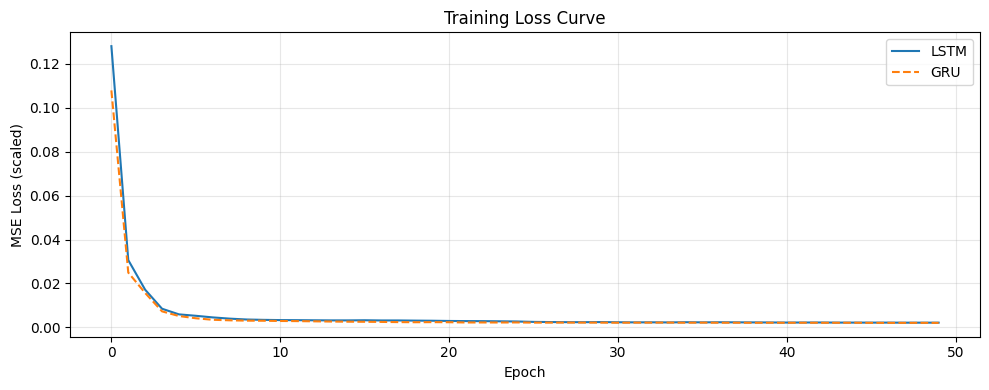

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_history, label="LSTM", linewidth=1.5)
ax.plot(gru_history,  label="GRU",  linewidth=1.5, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("Training Loss Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8 . Evaluation - MSE, RMSE, MAE

In [9]:
def predict(model, loader):
    """Run inference and return predictions & targets as numpy arrays (scaled)."""
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb.to(device)).cpu().numpy()
            all_preds.append(pred)
            all_targets.append(yb.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)


def inverse_transform_3d(arr, scaler):
    """Inverse-scale a (N, output_len, F) array back to original scale."""
    N, T, F = arr.shape
    return scaler.inverse_transform(arr.reshape(N * T, F)).reshape(N, T, F)


def compute_metrics(true_inv, pred_inv):
    """Compute MSE, RMSE, MAE across all timesteps and features."""
    t = true_inv.reshape(-1, true_inv.shape[-1])
    p = pred_inv.reshape(-1, pred_inv.shape[-1])
    mse  = mean_squared_error(t, p)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(t, p)
    return mse, rmse, mae


# -- Predict on test set -------------------------------------------------------
lstm_preds_sc, targets_sc = predict(lstm_model, test_loader)
gru_preds_sc,  _          = predict(gru_model,  test_loader)

# Invert normalisation
lstm_preds = inverse_transform_3d(lstm_preds_sc, scaler)
gru_preds  = inverse_transform_3d(gru_preds_sc,  scaler)
true_vals  = inverse_transform_3d(targets_sc,    scaler)

# -- Metrics -------------------------------------------------------------------
lstm_mse, lstm_rmse, lstm_mae = compute_metrics(true_vals, lstm_preds)
gru_mse,  gru_rmse,  gru_mae  = compute_metrics(true_vals, gru_preds)

metrics_df = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE":   [lstm_mse,  gru_mse],
    "RMSE":  [lstm_rmse, gru_rmse],
    "MAE":   [lstm_mae,  gru_mae],
})
print(metrics_df.to_string(index=False))

Model          MSE         RMSE          MAE
 LSTM 2.481198e+27 4.981162e+13 7.788963e+12
  GRU 2.510137e+27 5.010127e+13 7.724841e+12


## 9 . Per-Feature Metrics Bar Chart

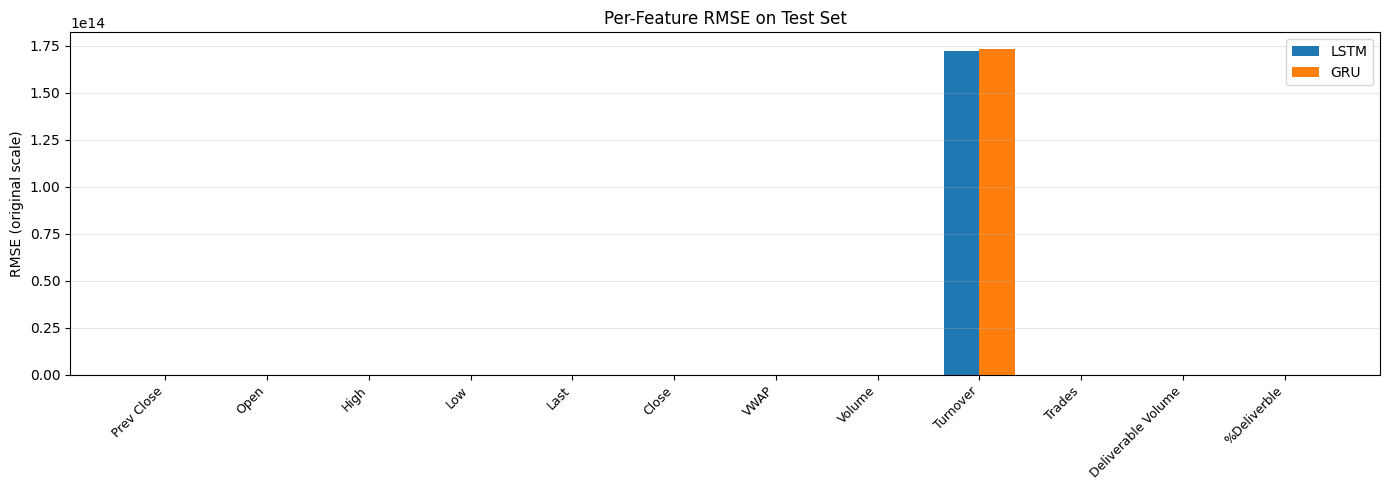

In [10]:
def per_feature_rmse(true_inv, pred_inv, feature_names):
    """Return a dict of {feature: RMSE} computed over all samples & timesteps."""
    N, T, F = true_inv.shape
    t = true_inv.reshape(N * T, F)
    p = pred_inv.reshape(N * T, F)
    return {feat: math.sqrt(mean_squared_error(t[:, i], p[:, i]))
            for i, feat in enumerate(feature_names)}


lstm_feat_rmse = per_feature_rmse(true_vals, lstm_preds, FEATURE_COLS)
gru_feat_rmse  = per_feature_rmse(true_vals, gru_preds,  FEATURE_COLS)

x = np.arange(len(FEATURE_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, [lstm_feat_rmse[f] for f in FEATURE_COLS], width, label="LSTM")
ax.bar(x + width/2, [gru_feat_rmse[f]  for f in FEATURE_COLS], width, label="GRU")
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("RMSE (original scale)")
ax.set_title("Per-Feature RMSE on Test Set")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10 . Date-Wise Prediction vs True Values

We flatten all test windows and plot a single time-series for each feature, showing both the true values and what the LSTM / GRU predicted on the **same dates**.

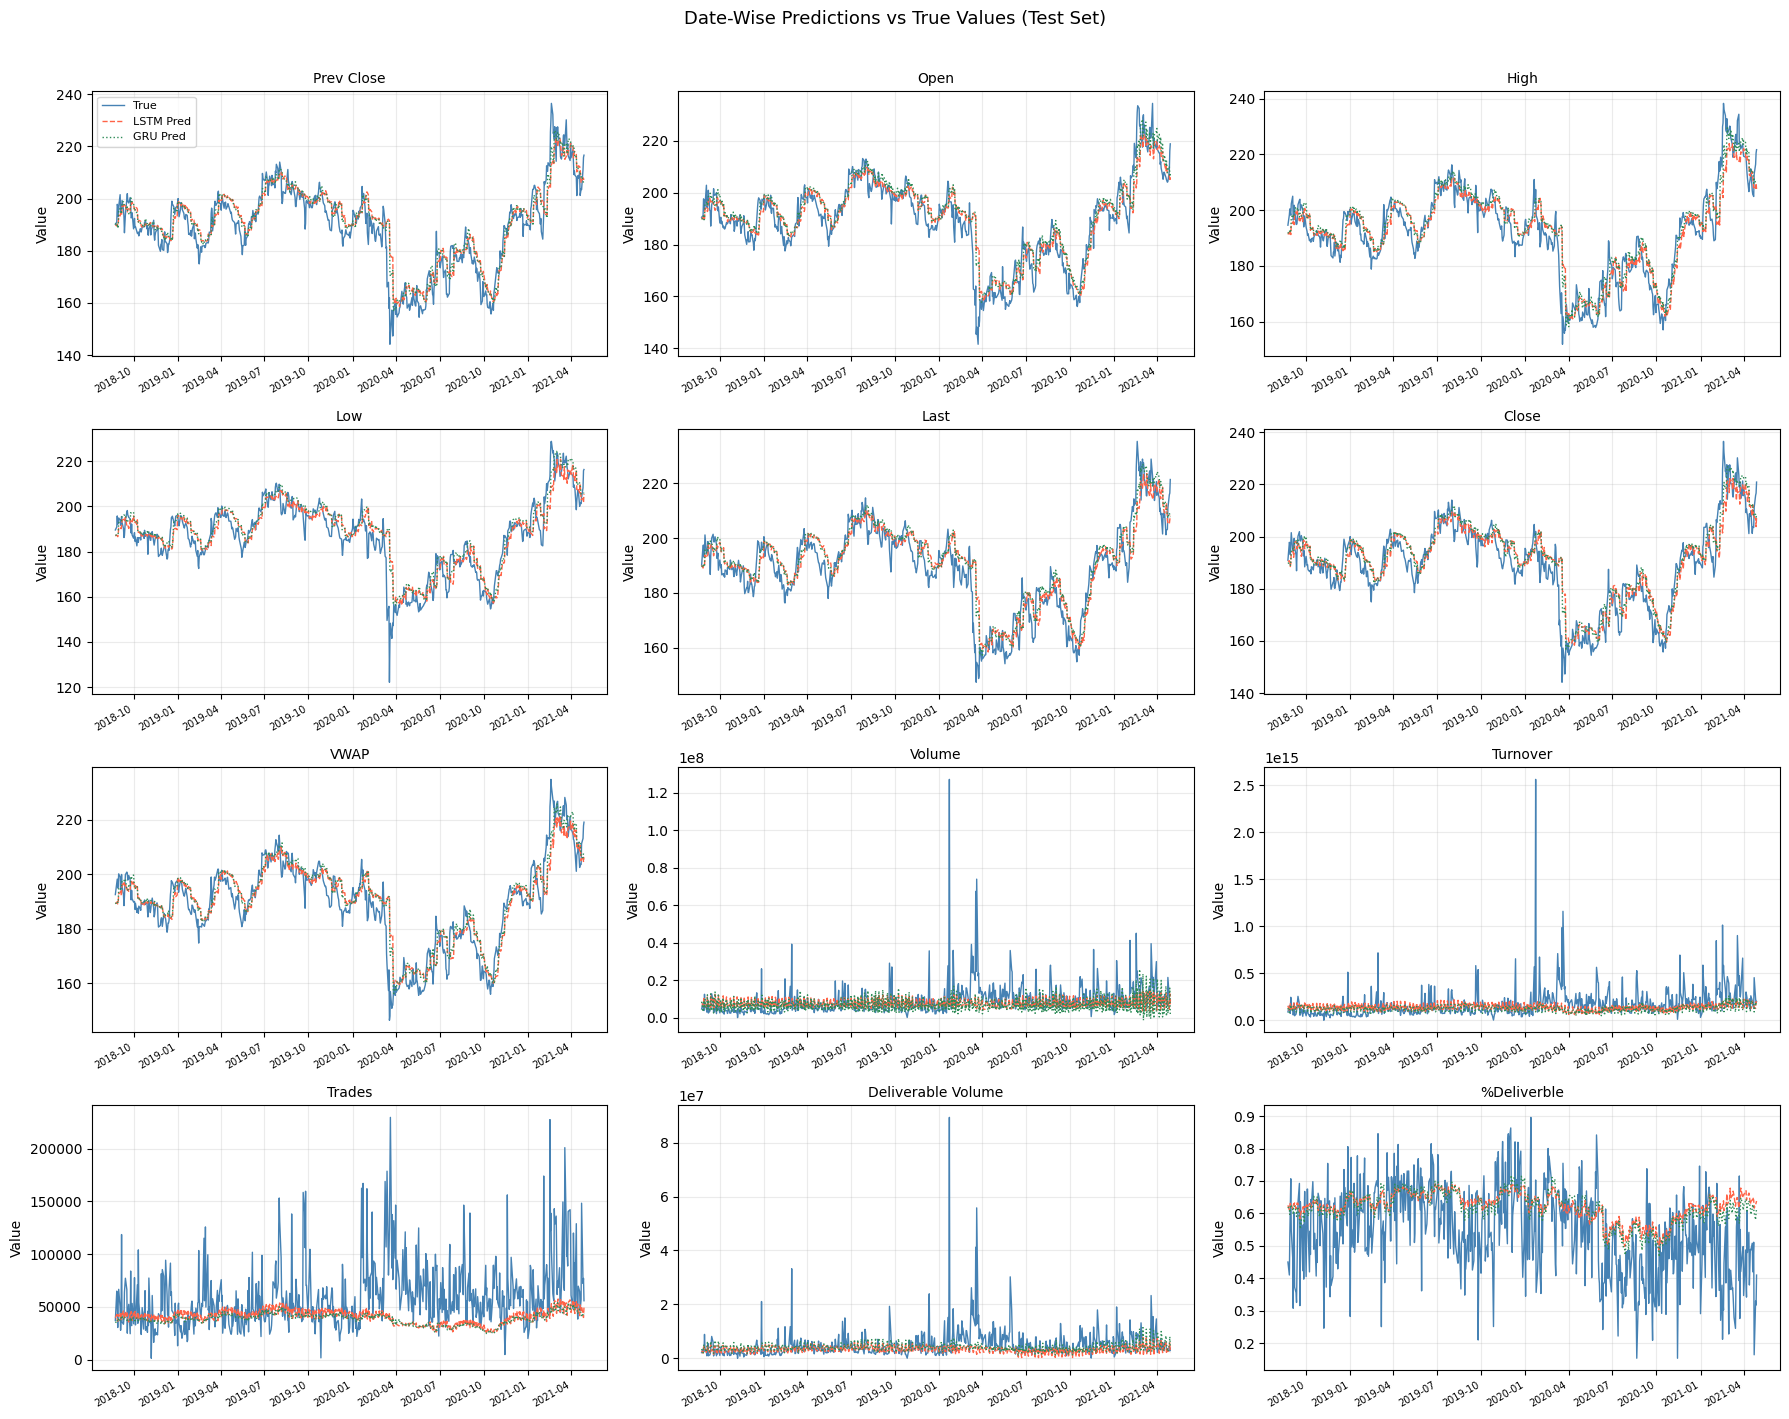

In [11]:
def flatten_windowed(arr_3d, date_grid_2d):
    """
    Collapse (N, output_len, F) windows into one chronological series.
    Dates shared by overlapping windows are averaged.
    """
    N, T, F = arr_3d.shape
    date_map = {}
    for i in range(N):
        for t in range(T):
            d = pd.Timestamp(date_grid_2d[i, t])
            date_map.setdefault(d, []).append(arr_3d[i, t])

    sorted_dates = sorted(date_map)
    mean_vals = np.array([np.mean(date_map[d], axis=0) for d in sorted_dates])
    return np.array(sorted_dates), mean_vals


flat_dates, flat_true      = flatten_windowed(true_vals,  test_pred_dates)
_,          flat_lstm_pred = flatten_windowed(lstm_preds, test_pred_dates)
_,          flat_gru_pred  = flatten_windowed(gru_preds,  test_pred_dates)

# -- One subplot per feature ---------------------------------------------------
ncols = 3
nrows = math.ceil(len(FEATURE_COLS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.plot(flat_dates, flat_true[:, i],      label="True",      lw=1.0, color="steelblue")
    ax.plot(flat_dates, flat_lstm_pred[:, i], label="LSTM Pred", lw=1.0, color="tomato",  ls="--")
    ax.plot(flat_dates, flat_gru_pred[:, i],  label="GRU Pred",  lw=1.0, color="seagreen", ls=":")
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel("Value")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)
    ax.grid(True, alpha=0.25)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Date-Wise Predictions vs True Values (Test Set)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11 . Close Price Focus Plot (LSTM vs GRU)

A single clean chart on the `Close` price - the most commonly evaluated feature - for a clearer visual comparison.

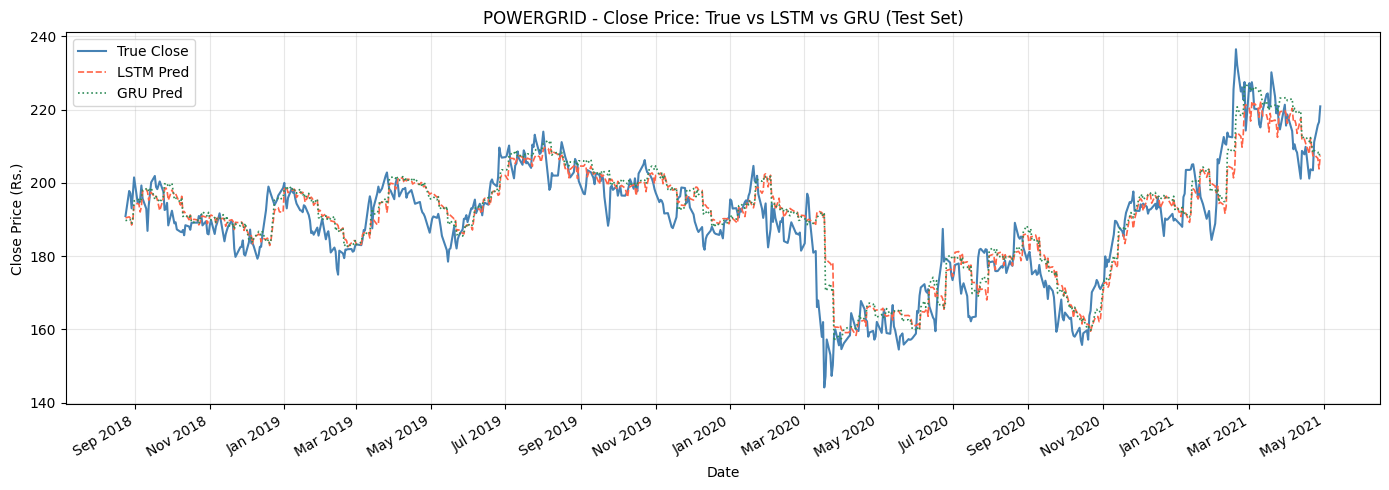

In [12]:
close_idx = FEATURE_COLS.index("Close")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(flat_dates, flat_true[:, close_idx],      label="True Close",  linewidth=1.5, color="steelblue")
ax.plot(flat_dates, flat_lstm_pred[:, close_idx], label="LSTM Pred",   linewidth=1.2, color="tomato",   linestyle="--")
ax.plot(flat_dates, flat_gru_pred[:, close_idx],  label="GRU Pred",    linewidth=1.2, color="seagreen",  linestyle=":")

ax.set_xlabel("Date")
ax.set_ylabel("Close Price (Rs.)")
ax.set_title("POWERGRID - Close Price: True vs LSTM vs GRU (Test Set)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12 . Summary

In [14]:
print("=" * 55)
print("  FINAL TEST-SET METRICS  (original scale, all features)")
print("=" * 55)
print(metrics_df.to_string(index=False))
print()
print(f"Input window  : {INPUT_LEN} days")
print(f"Output horizon: {OUTPUT_LEN} days")
print(f"Overlap       : {OVERLAP} days  ->  stride = {INPUT_LEN - OVERLAP} days")
print(f"Features used : {len(FEATURE_COLS)} -> {FEATURE_COLS}")

  FINAL TEST-SET METRICS  (original scale, all features)
Model          MSE         RMSE          MAE
 LSTM 2.481198e+27 4.981162e+13 7.788963e+12
  GRU 2.510137e+27 5.010127e+13 7.724841e+12

Input window  : 10 days
Output horizon: 5 days
Overlap       : 5 days  ->  stride = 5 days
Features used : 12 -> ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']
